In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, layers # type: ignore
from keras.preprocessing.image import  ImageDataGenerator  # type: ignore
from keras.utils import load_img
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense # type: ignore
from keras import  backend as K
from keras import layers

import os
import numpy as np
import pandas as pd

from random import randint
from PIL import  Image

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
main_dir = r"E:/College/Project/BoneFractureDetectionFlask/Dataset"
train_dir= main_dir + r"/train"
validation_dir=main_dir+r"/val"
test_dir=main_dir+r"/test"

nb_train_samples=6624
nb_validation_samples=57
epochs=20
batch_size=18




In [4]:
train_f=train_dir+"fractured/"
train_nf=train_dir+"non-fractured/"

print("length of cases in training set:",len(os.listdir(r"E:/College/Project/BoneFractureDetectionFlask/Dataset/train/fractured/"))+len(os.listdir(r"E:/College/Project/BoneFractureDetectionFlask/Dataset/train/not_fractured")))
print(len(validation_dir))


length of cases in training set: 6624
57


Text(0.5, 1.0, 'Not Fractured')

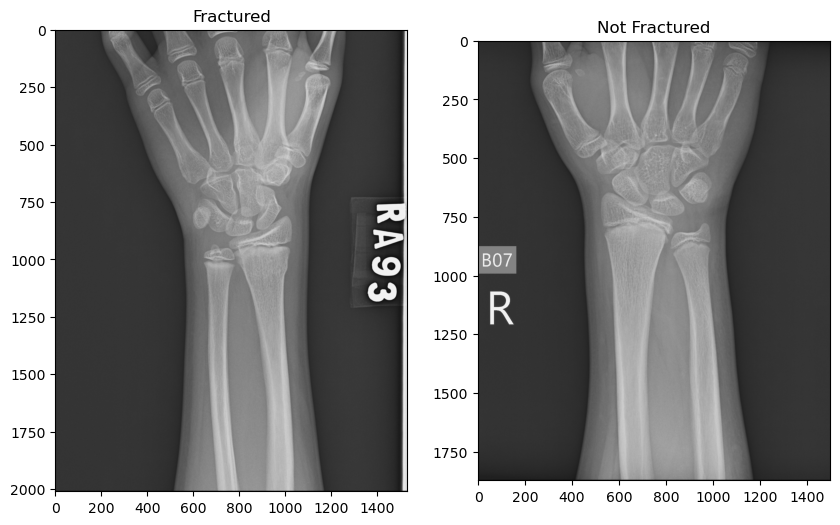

In [5]:
img_name='1.jpg'
img_fractured=load_img(r"E:/College/Project/BoneFractureDetectionFlask/Dataset/train/fractured/1.jpg")

img_name1='1.jpg'
img_not_fractured=load_img(r"E:/College/Project/BoneFractureDetectionFlask/Dataset/train/not_fractured/1.jpg")

fig, axes = plt.subplots(1, 2, figsize=(10,6))
axes[0].imshow(img_fractured)
axes[0].set_title('Fractured')
axes[1].imshow(img_not_fractured)
axes[1].set_title('Not Fractured')

In [6]:
img_height, img_width=180, 180

if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape= (img_width,img_height, 3)

In [7]:
train_datagen= ImageDataGenerator(
    rescale=1./ 255,
    shear_range=0.2,
    zoom_range = 0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width,img_height),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width,img_height),
    batch_size=32,
    class_mode='binary'
)

Found 6624 images belonging to 2 classes.
Found 1892 images belonging to 2 classes.
Found 947 images belonging to 2 classes.


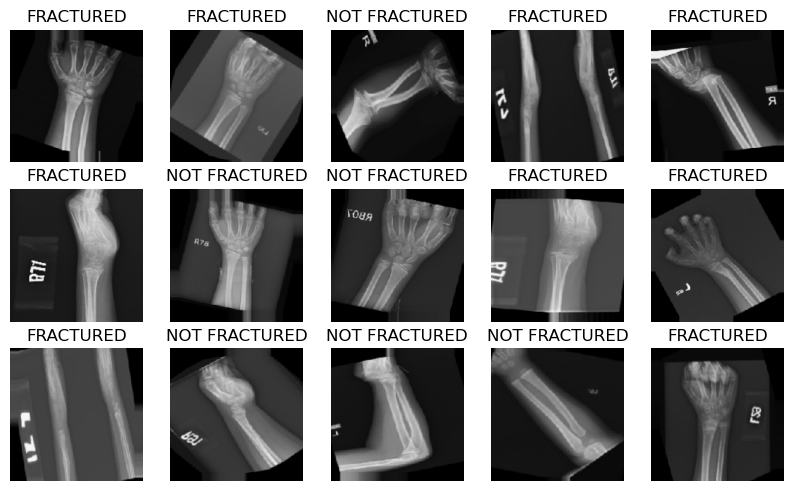

In [8]:
image_batch, label_batch=next(iter(train_generator))

def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10,10))
    for n in range(15):
        ax = plt.subplot(5, 5, n + 1)
        plt.imshow(image_batch[n])
        if label_batch[n]:
            plt.title("NOT FRACTURED")
        else:
            plt.title("FRACTURED")
        plt.axis("off")

show_batch(image_batch, label_batch)

In [9]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 180, 180, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 90, 90, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 22, 22, 64)       

In [10]:
model.compile(loss='binary_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])

In [11]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

In [14]:
model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples//batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples//batch_size,
    callbacks=[early_stopping_cb]
)

Epoch 1/20


368/368 [==============================] - 131s 353ms/step - loss: 0.6619 - accuracy: 0.5934 - val_loss: 0.5845 - val_accuracy: 0.7396
Epoch 2/20
368/368 [==============================] - 88s 240ms/step - loss: 0.6193 - accuracy: 0.6407 - val_loss: 0.5217 - val_accuracy: 0.7604
Epoch 3/20
368/368 [==============================] - 89s 241ms/step - loss: 0.5728 - accuracy: 0.6913 - val_loss: 0.4691 - val_accuracy: 0.7812
Epoch 4/20
368/368 [==============================] - 89s 241ms/step - loss: 0.5070 - accuracy: 0.7482 - val_loss: 0.4567 - val_accuracy: 0.7604
Epoch 5/20
368/368 [==============================] - 88s 239ms/step - loss: 0.4301 - accuracy: 0.8007 - val_loss: 0.2698 - val_accuracy: 0.9062
Epoch 6/20
368/368 [==============================] - 91s 247ms/step - loss: 0.3626 - accuracy: 0.8324 - val_loss: 0.2220 - val_accuracy: 0.8854
Epoch 7/20
368/368 [==============================] - 85s 231ms/step - loss: 0.3238 - accuracy: 0.8646 - val_loss: 0.1282 - val

In [15]:
scores=model.evaluate_generator(test_generator)

print("Loss of the model: %.2f"% (scores[0]))
print('Accuracy of the model: %.2f%%' % (scores[1]*100))

C:\Users\sruja\AppData\Local\Temp\ipykernel_16012\2112915994.py:1: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  scores=model.evaluate_generator(test_generator)


Loss of the model: 0.08
Accuracy of the model: 97.47%


In [12]:
from tensorflow import keras
from keras.models import load_model
from keras.utils import load_img
import matplotlib.pyplot as plt
%matplotlib inline

img_height, img_width=180, 180

# model.save("bonefracture.h5")

1/1 [==============================] - 0s 100ms/step
predicted: FRACTURED


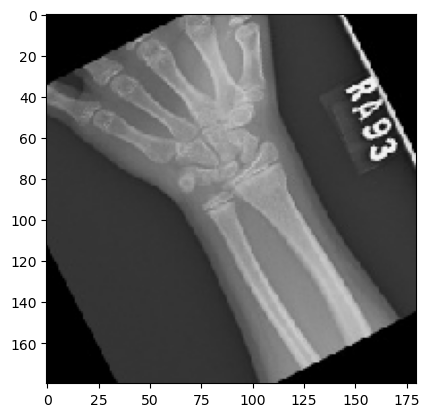

In [15]:
def predict_image(filename):
    img=load_img(filename, target_size=(img_height, img_width))
    image=keras.preprocessing.image.img_to_array(img)
    image=image/255.0
    image=image.reshape(1,180,180,3)
    model=load_model('bonefracture.h5')
    prediction = model.predict(image)
    plt.imshow(img)
    if (prediction[0]>0.5):
        print("predicted: NOT_FRACTURED")
    else:
        print("predicted: FRACTURED")

predict_image(r"E:/College/Project/BoneFractureDetectionFlask/Dataset/val/fractured/1-rotated3.jpg")